In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

In [53]:
# 필요 라이브러리 import
import numpy as np
import seaborn as sns # iris데이터
import pandas as pd # 원핫인코딩(get_dummies)
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from sklearn.preprocessing import MinMaxScaler, LabelEncoder # 스케일 조정, 라벨인코딩(문자->숫자)
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout, add
from sklearn.model_selection import train_test_split # 층화추출 데이터 분할용
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt # 학습 과정 시각화
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score
from tensorflow.keras import Model # 모델 생성 : 입력층과 출력층을 이용

In [ ]:
# 데이터 생성 및 전처리 (라벨인코딩만 하고, 원핫인코딩X)

In [6]:
from sklearn import datasets
iris = datasets.load_iris()
# iris.keys()
iris_X = iris.data
iris_y = iris.target # 라벨인코딩이 이미 되어있음
iris_X.shape, iris_y.shape
train_X, test_X, train_y, test_y = train_test_split(iris_X, iris_y,
                                                    stratify=iris_y,
                                                    test_size=0.1,
                                                    )
train_X.shape, train_y.shape, test_X.shape, test_y.shape

((135, 4), (135,), (15, 4), (15,))

# 1. 기본적인 DNN(원핫인코딩X)

In [8]:
# 모델 설정
# model = Sequential()
# model.add(Input(4,))
# model.add(Dense(units=50, activation='relu'))
# model.add(Dense(units=30, activation='relu'))
# model.add(Dense(units=3, activation='softmax'))

# add의 작동원리 => 내부 list에 append하는 방식으로 아래와 완전히 동일

model=Sequential([
    Input(4,),
    Dense(units=50, activation='relu'),
    Dense(units=30, activation='relu'),
    Dense(units=3, activation='softmax'),
])
model.summary() # params : 1873

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 50)                250       
                                                                 
 dense_4 (Dense)             (None, 30)                1530      
                                                                 
 dense_5 (Dense)             (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________


In [9]:
# 모델 학습 설정
model.compile(loss='sparse_categorical_crossentropy', # 라벨인코딩만 되어 있는 경우 원핫인코딩 자동
             optimizer='adam',
             metrics=['accuracy'])
# 학습
earlystopping = EarlyStopping(patience=50) # monitor = 'val_loss' 기본값
hist = model.fit(train_X, train_y, epochs=1000, batch_size=40, callbacks=[earlystopping], validation_split=0.2)

Epoch 1/1000
3/3 [==============================] - 1s 104ms/step - loss: 1.0413 - accuracy: 0.6574 - val_loss: 0.9507 - val_accuracy: 0.7037
Epoch 2/1000
3/3 [==============================] - 0s 16ms/step - loss: 0.9539 - accuracy: 0.6574 - val_loss: 0.8966 - val_accuracy: 0.7037
Epoch 3/1000
3/3 [==============================] - 0s 16ms/step - loss: 0.8879 - accuracy: 0.6574 - val_loss: 0.8313 - val_accuracy: 0.7037
Epoch 4/1000
3/3 [==============================] - 0s 16ms/step - loss: 0.8342 - accuracy: 0.6574 - val_loss: 0.7681 - val_accuracy: 0.7037
Epoch 5/1000
3/3 [==============================] - 0s 17ms/step - loss: 0.7860 - accuracy: 0.6574 - val_loss: 0.7072 - val_accuracy: 0.7037
Epoch 6/1000
3/3 [==============================] - 0s 18ms/step - loss: 0.7427 - accuracy: 0.6574 - val_loss: 0.6529 - val_accuracy: 0.7037
Epoch 7/1000
3/3 [==============================] - 0s 18ms/step - loss: 0.7037 - accuracy: 0.6574 - val_loss: 0.6058 - val_accuracy: 0.7037
Epoch 8/1000

Epoch 59/1000
3/3 [==============================] - 0s 16ms/step - loss: 0.2422 - accuracy: 0.9722 - val_loss: 0.1655 - val_accuracy: 0.9630
Epoch 60/1000
3/3 [==============================] - 0s 16ms/step - loss: 0.2372 - accuracy: 0.9815 - val_loss: 0.1623 - val_accuracy: 0.9630
Epoch 61/1000
3/3 [==============================] - 0s 17ms/step - loss: 0.2332 - accuracy: 0.9815 - val_loss: 0.1593 - val_accuracy: 0.9630
Epoch 62/1000
3/3 [==============================] - 0s 17ms/step - loss: 0.2278 - accuracy: 0.9815 - val_loss: 0.1559 - val_accuracy: 0.9630
Epoch 63/1000
3/3 [==============================] - 0s 17ms/step - loss: 0.2239 - accuracy: 0.9815 - val_loss: 0.1527 - val_accuracy: 1.0000
Epoch 64/1000
3/3 [==============================] - 0s 17ms/step - loss: 0.2204 - accuracy: 0.9815 - val_loss: 0.1496 - val_accuracy: 1.0000
Epoch 65/1000
3/3 [==============================] - 0s 17ms/step - loss: 0.2150 - accuracy: 0.9815 - val_loss: 0.1462 - val_accuracy: 1.0000
Epoch 

3/3 [==============================] - 0s 16ms/step - loss: 0.0958 - accuracy: 0.9722 - val_loss: 0.0670 - val_accuracy: 1.0000
Epoch 117/1000
3/3 [==============================] - 0s 16ms/step - loss: 0.0950 - accuracy: 0.9722 - val_loss: 0.0674 - val_accuracy: 1.0000
Epoch 118/1000
3/3 [==============================] - 0s 17ms/step - loss: 0.0937 - accuracy: 0.9722 - val_loss: 0.0684 - val_accuracy: 1.0000
Epoch 119/1000
3/3 [==============================] - 0s 18ms/step - loss: 0.0951 - accuracy: 0.9722 - val_loss: 0.0685 - val_accuracy: 1.0000
Epoch 120/1000
3/3 [==============================] - 0s 17ms/step - loss: 0.0924 - accuracy: 0.9722 - val_loss: 0.0651 - val_accuracy: 1.0000
Epoch 121/1000
3/3 [==============================] - 0s 18ms/step - loss: 0.0927 - accuracy: 0.9815 - val_loss: 0.0635 - val_accuracy: 0.9630
Epoch 122/1000
3/3 [==============================] - 0s 17ms/step - loss: 0.0926 - accuracy: 0.9722 - val_loss: 0.0643 - val_accuracy: 1.0000
Epoch 123/1000

3/3 [==============================] - 0s 17ms/step - loss: 0.0697 - accuracy: 0.9722 - val_loss: 0.0543 - val_accuracy: 1.0000
Epoch 174/1000
3/3 [==============================] - 0s 19ms/step - loss: 0.0735 - accuracy: 0.9722 - val_loss: 0.0529 - val_accuracy: 0.9630
Epoch 175/1000
3/3 [==============================] - 0s 17ms/step - loss: 0.0694 - accuracy: 0.9722 - val_loss: 0.0535 - val_accuracy: 1.0000
Epoch 176/1000
3/3 [==============================] - 0s 18ms/step - loss: 0.0680 - accuracy: 0.9722 - val_loss: 0.0561 - val_accuracy: 1.0000
Epoch 177/1000
3/3 [==============================] - 0s 16ms/step - loss: 0.0703 - accuracy: 0.9815 - val_loss: 0.0583 - val_accuracy: 0.9630
Epoch 178/1000
3/3 [==============================] - 0s 17ms/step - loss: 0.0704 - accuracy: 0.9815 - val_loss: 0.0555 - val_accuracy: 1.0000
Epoch 179/1000
3/3 [==============================] - 0s 17ms/step - loss: 0.0679 - accuracy: 0.9722 - val_loss: 0.0526 - val_accuracy: 0.9630
Epoch 180/1000

3/3 [==============================] - 0s 16ms/step - loss: 0.0620 - accuracy: 0.9722 - val_loss: 0.0527 - val_accuracy: 1.0000
Epoch 231/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0620 - accuracy: 0.9722 - val_loss: 0.0525 - val_accuracy: 1.0000
Epoch 232/1000
3/3 [==============================] - 0s 16ms/step - loss: 0.0619 - accuracy: 0.9722 - val_loss: 0.0516 - val_accuracy: 0.9630
Epoch 233/1000
3/3 [==============================] - 0s 16ms/step - loss: 0.0660 - accuracy: 0.9722 - val_loss: 0.0517 - val_accuracy: 0.9630
Epoch 234/1000
3/3 [==============================] - 0s 12ms/step - loss: 0.0604 - accuracy: 0.9722 - val_loss: 0.0532 - val_accuracy: 1.0000
Epoch 235/1000
3/3 [==============================] - 0s 17ms/step - loss: 0.0620 - accuracy: 0.9815 - val_loss: 0.0590 - val_accuracy: 0.9630
Epoch 236/1000
3/3 [==============================] - 0s 18ms/step - loss: 0.0644 - accuracy: 0.9815 - val_loss: 0.0564 - val_accuracy: 0.9630
Epoch 237/1000

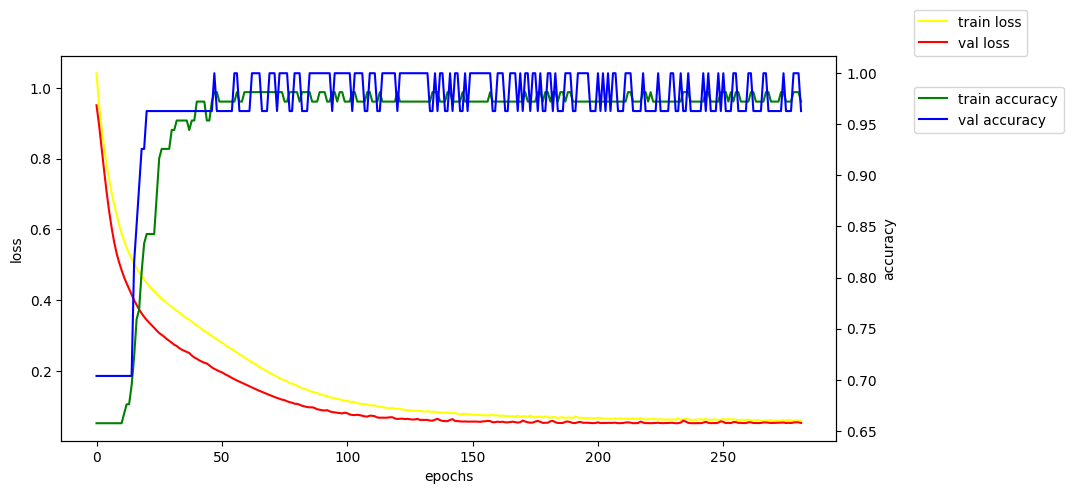

In [10]:
# 학습 과정 확인하기
# hist.history.keys() # loss accuracy val_loss val_accuracy
fig, loss_ax = plt.subplots(figsize = (10,5))
loss_ax.plot(hist.history.get('loss'), color='yellow', label='train loss')
loss_ax.plot(hist.history.get('val_loss'), color='red', label='val loss')
loss_ax.legend(loc=(1.1,1))
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history.get('accuracy'), color='green', label='train accuracy')
acc_ax.plot(hist.history.get('val_accuracy'), color='blue', label='val accuracy')
acc_ax.legend(loc=(1.1,0.8))
acc_ax.set_ylabel('accuracy')
plt.show()

In [27]:
model.predict(np.array([test_X[0]]))

1/1 [==============================] - 0s 35ms/step


array([[1.10186134e-04, 9.59255874e-01, 4.06339541e-02]], dtype=float32)

# 2. sklearn 이용
- 원핫인코딩을 하지 않고 라벨인코딩까지 진행. numpy배열

In [26]:
from sklearn.neural_network import MLPClassifier

In [39]:
# 머신러닝 3절 인공신경망(43p) 참조
mlp_model = MLPClassifier(hidden_layer_sizes=(50,30),
                     activation = 'relu',
                     solver = 'adam',
                     alpha = 0.0001, # 과적합 방지 강도
                     batch_size=40,
                     max_iter=1000, # 학습 회수 : epochs
                     early_stopping=True, # 조기 종료 활성화, val_loss 기준
                     n_iter_no_change= 50, # patience와 동일
                     validation_fraction=0.1, # 검증셋 비율
                     warm_start=False, # True일 경우 이전 학습에 이어서 학습 
                     ) # history 반환X 그래프 불가

In [40]:
mlp_model.fit(train_X,train_y)

MLPClassifier(batch_size=40, early_stopping=True, hidden_layer_sizes=(50, 30),
              max_iter=1000, n_iter_no_change=50)

In [47]:
# 모델 평가 : 그래프는 불가, accuracy(test_X, test_y), recall(test_y,y_hat), precision(test_y,y_hat)으로 평가
accuracy = mlp_model.score(test_X,test_y) # accuracy
y_hat = mlp_model.predict(test_X)
recall = recall_score(test_y,y_hat,average='weighted')
precision = precision_score(test_y,y_hat,average='weighted')
print('accuracy 정확도 :', accuracy)
print('recall 재현율 :', recall)
print('precision 정밀도 :', precision)
print('교차표')
display(pd.crosstab(test_y,y_hat,rownames=['실제값'],colnames=['예측값']))

accuracy 정확도 : 0.9333333333333333
recall 재현율 : 0.9333333333333333
precision 정밀도 : 0.9444444444444445
교차표


예측값,0,1,2
실제값,,,
0,5,0,0
1,0,4,1
2,0,0,5


# 3. 클래스 이용

In [48]:
class DNNClassifier :
    @staticmethod
    def build(input_dim=4, activation='relu',optimizer = 'adam') :
        ''' 모델 구성 '''
        model = Sequential([
            Input(input_dim,),
            Dense(50, activation=activation),
            Dense(30, activation=activation),
            Dense(3, activation='softmax'),
        ])
        ''' 학습과정 설정 '''
        model.compile(loss='sparse_categorical_crossentropy',
                     optimizer = optimizer,
                     metrics = ['accuracy'])
#         model = Sequential()
#         model.add(Input(input_dim,))
#         model.add(Dense(units=50, activation=activation))
#         model.add(Dense(units=30, activation=activation))
#         model.add(Dense(units=3, activation='softmax'))
        return model

In [50]:
# 모델
model = DNNClassifier.build(input_dim=4, activation='relu',optimizer='sgd')
model.summary()
hist = model.fit(train_X,train_y, epochs=50, validation_split=0.2)

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_9 (Dense)             (None, 50)                250       
                                                                 
 dense_10 (Dense)            (None, 30)                1530      
                                                                 
 dense_11 (Dense)            (None, 3)                 93        
                                                                 
Total params: 1,873
Trainable params: 1,873
Non-trainable params: 0
_________________________________________________________________
Epoch 1/50
4/4 [==============================] - 1s 66ms/step - loss: 1.3108 - accuracy: 0.4815 - val_loss: 1.4695 - val_accuracy: 0.3333
Epoch 2/50
4/4 [==============================] - 0s 13ms/step - loss: 1.2269 - accuracy: 0.3704 - val_loss: 1.3813 - val_accuracy: 0.2222
Epoch 3/50
4/4 [======================

In [52]:
loss, acc = model.evaluate(test_X,test_y)
loss, acc

1/1 [==============================] - 0s 27ms/step - loss: 0.3994 - accuracy: 0.8667


(0.39939746260643005, 0.8666666746139526)

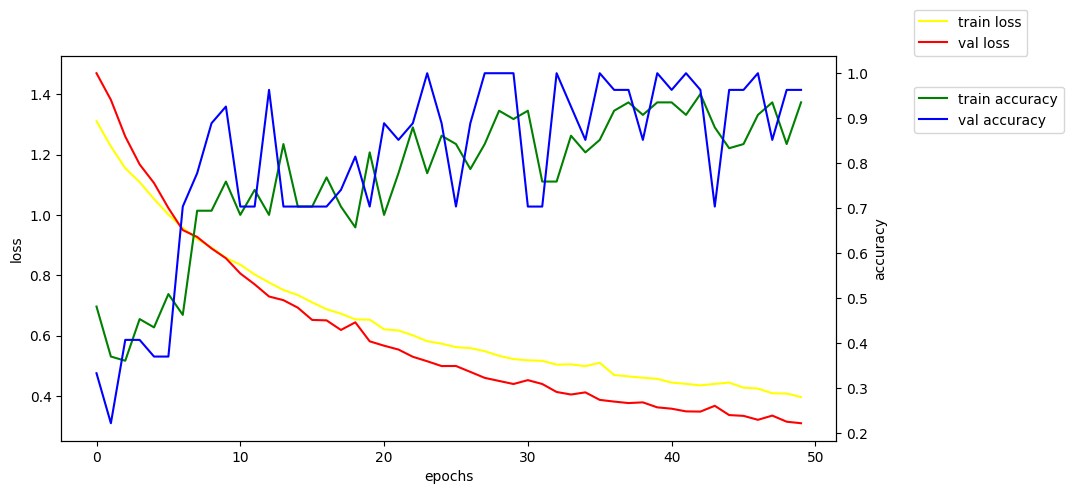

In [51]:
# hist.history.keys() # loss accuracy val_loss val_accuracy
fig, loss_ax = plt.subplots(figsize = (10,5))
loss_ax.plot(hist.history.get('loss'), color='yellow', label='train loss')
loss_ax.plot(hist.history.get('val_loss'), color='red', label='val loss')
loss_ax.legend(loc=(1.1,1))
loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history.get('accuracy'), color='green', label='train accuracy')
acc_ax.plot(hist.history.get('val_accuracy'), color='blue', label='val accuracy')
acc_ax.legend(loc=(1.1,0.8))
acc_ax.set_ylabel('accuracy')
plt.show()

# 4. 함수형 API 이용하기
- 병렬처리 : 속도 높이려고
- 레지듀얼블록(Residual block) : 모델의 성능을 높이려고 -> 자연어처리, 이미지 처리

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split # 데이터 분할에 사용
from tensorflow.keras import Model # 모델 생성 (입력층과 출력층 사용)
from tensorflow.keras.layers import Dense, Input, add, concatenate # add : 레지듀얼블록 concatenate : 병렬처리에 필요
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

In [ ]:
from sklearn import datasets
iris = datasets.load_iris()
# iris.keys()
iris_X = iris.data
iris_y = iris.target # 라벨인코딩이 이미 되어있음
iris_X.shape, iris_y.shape
train_X, test_X, train_y, test_y = train_test_split(iris_X, iris_y,
                                                    stratify=iris_y,
                                                    test_size=0.1,
                                                    )
train_X.shape, train_y.shape, test_X.shape, test_y.shape